# コンシューマーゲーム事業部（ゲーム開発部）開発状況分析

## 分析内容
1. データ読み込みと前処理
2. チケットステータス・優先度分布
3. スプリント別ベロシティ
4. バックログ積み上げ推移
5. 見積もりと実績の工数比較
6. ベロシティ将来予測（線形回帰）
7. ブロッカー分析
8. 分析サマリー

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
from sklearn.linear_model import LinearRegression
import warnings, os
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_theme(style='whitegrid')
print('ライブラリ読み込み完了')

ライブラリ読み込み完了


## 1. データ読み込みと前処理

In [2]:
notebook_dir = os.path.dirname(os.path.abspath('dev_analysis.ipynb'))
csv_path = os.path.join(notebook_dir, '../../temp/dev-tasks.csv')
df_all = pd.read_csv(csv_path)
df = df_all[df_all['DepartmentName'] == 'ゲーム開発部'].copy()
for col in ['DueDate', 'StartedAt', 'CompletedAt']:
    df[col] = pd.to_datetime(df[col], errors='coerce')
df['SprintNum'] = df['SprintName'].str.extract(r'Sprint\s*(\d+)').astype(float)
print(f'全チケット数: {len(df)}')
print('\nステータス分布:')
print(df['Status'].value_counts())
print('\nプロジェクト一覧:')
print(df['ProjectName'].value_counts())

全チケット数: 104

ステータス分布:
Status
in_progress    35
open           24
done           23
review         16
blocked         6
Name: count, dtype: int64

プロジェクト一覧:
ProjectName
プロジェクト 50: UI改善 v2.0         22
プロジェクト 25: 基盤刷新 v1.6         21
プロジェクト 01: 基盤刷新 v1.9         19
プロジェクト 07: データ分析基盤 v1.4      16
プロジェクト 32: 機能追加 v4.2         15
プロジェクト 19: パフォーマンス改善 v1.9     6
プロジェクト 15: データ分析基盤 v1.2       5
Name: count, dtype: int64


## 2. チケットステータス・優先度・種別の分布

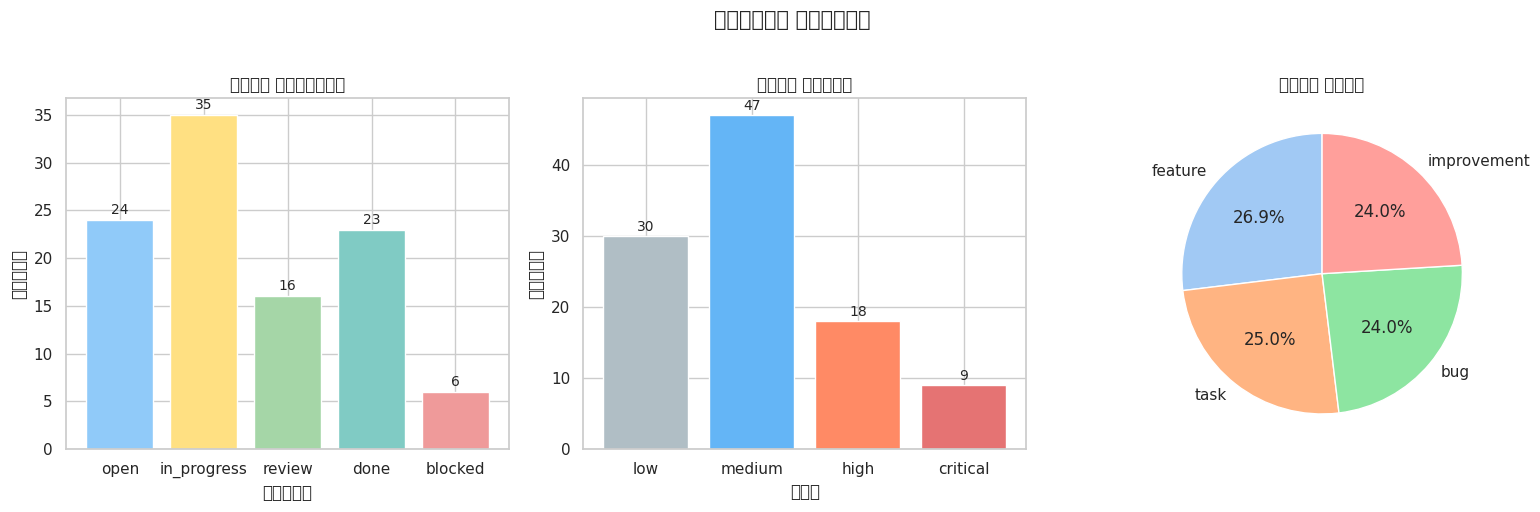

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
status_order = ['open', 'in_progress', 'review', 'done', 'blocked']
status_colors = {'open': '#90CAF9', 'in_progress': '#FFE082', 'review': '#A5D6A7', 'done': '#80CBC4', 'blocked': '#EF9A9A'}
status_counts = df['Status'].value_counts().reindex(status_order).fillna(0)
bars = axes[0].bar(status_counts.index, status_counts.values, color=[status_colors.get(s, '#BDBDBD') for s in status_counts.index], edgecolor='white')
axes[0].set_title('チケット ステータス分布')
axes[0].set_xlabel('ステータス')
axes[0].set_ylabel('チケット数')
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(int(val)), ha='center', va='bottom', fontsize=10)
priority_order = ['low', 'medium', 'high', 'critical']
priority_colors = ['#B0BEC5', '#64B5F6', '#FF8A65', '#E57373']
priority_counts = df['Priority'].value_counts().reindex(priority_order).fillna(0)
bars2 = axes[1].bar(priority_counts.index, priority_counts.values, color=priority_colors, edgecolor='white')
axes[1].set_title('チケット 優先度分布')
axes[1].set_xlabel('優先度')
axes[1].set_ylabel('チケット数')
for bar, val in zip(bars2, priority_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(int(val)), ha='center', va='bottom', fontsize=10)
type_counts = df['TicketType'].value_counts()
axes[2].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
axes[2].set_title('チケット 種別分布')
plt.suptitle('ゲーム開発部 チケット概要', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 3. スプリント別ベロシティ

スクラムでは各スプリントで完了したストーリーポイントの合計が「ベロシティ」です。
ベロシティの推移を見ることで、チームの生産性の傾向を把握できます。

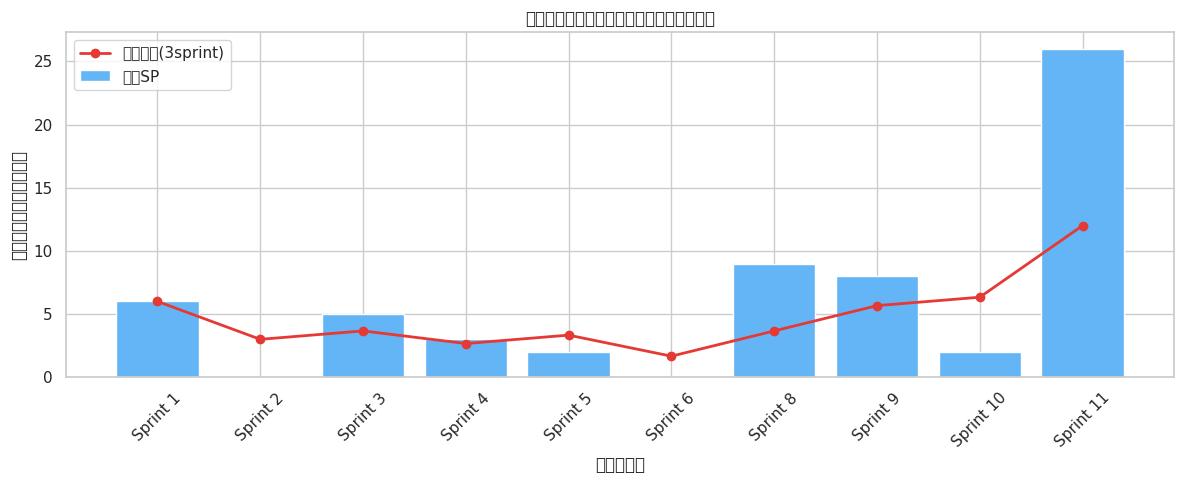

平均ベロシティ: 6.1 SP/スプリント
 スプリント番号  完了ストーリーポイント  移動平均(3sprint)
     1.0          6.0       6.000000
     2.0          0.0       3.000000
     3.0          5.0       3.666667
     4.0          3.0       2.666667
     5.0          2.0       3.333333
     6.0          0.0       1.666667
     8.0          9.0       3.666667
     9.0          8.0       5.666667
    10.0          2.0       6.333333
    11.0         26.0      12.000000


In [4]:
done_df = df[(df['Status'] == 'done') & df['SprintNum'].notna()].copy()
velocity = done_df.groupby('SprintNum')['StoryPoints'].sum().sort_index().reset_index()
velocity.columns = ['スプリント番号', '完了ストーリーポイント']
velocity['移動平均(3sprint)'] = velocity['完了ストーリーポイント'].rolling(3, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(12, 5))
sprint_labels = [f'Sprint {int(s)}' for s in velocity['スプリント番号']]
ax.bar(sprint_labels, velocity['完了ストーリーポイント'], color='#64B5F6', label='完了SP', edgecolor='white')
ax.plot(sprint_labels, velocity['移動平均(3sprint)'], color='#E53935', marker='o', linewidth=2, label='移動平均(3sprint)')
ax.set_title('スプリント別ベロシティ（ゲーム開発部）')
ax.set_xlabel('スプリント')
ax.set_ylabel('完了ストーリーポイント')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
avg_velocity = velocity['完了ストーリーポイント'].mean()
print(f'平均ベロシティ: {avg_velocity:.1f} SP/スプリント')
print(velocity.to_string(index=False))

## 4. バックログ積み上げ推移（スプリント別）

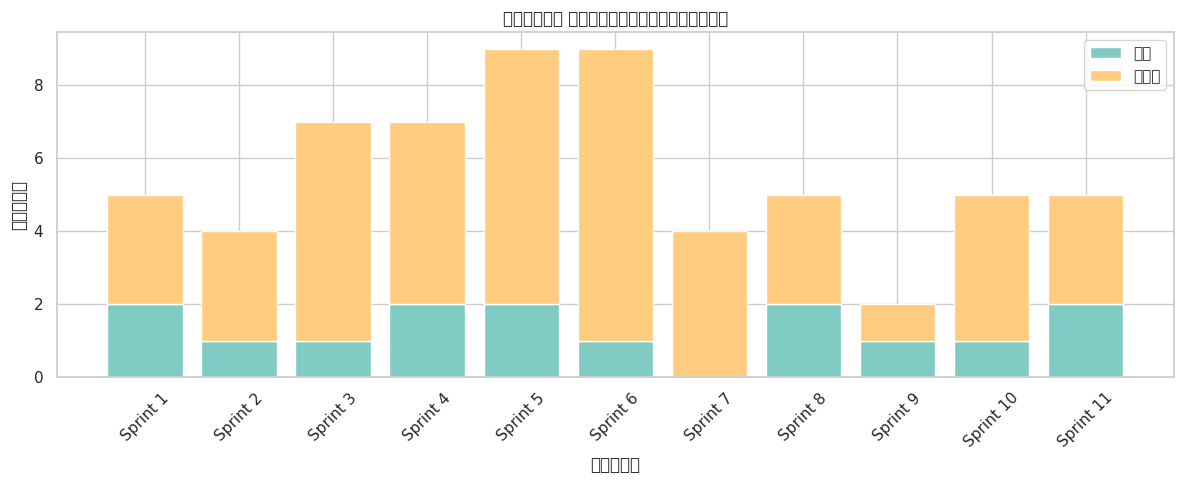

    スプリント  総チケット数  完了  未完了  完了率(%)
 Sprint 1       5   2    3    40.0
 Sprint 2       4   1    3    25.0
 Sprint 3       7   1    6    14.3
 Sprint 4       7   2    5    28.6
 Sprint 5       9   2    7    22.2
 Sprint 6       9   1    8    11.1
 Sprint 7       4   0    4     0.0
 Sprint 8       5   2    3    40.0
 Sprint 9       2   1    1    50.0
Sprint 10       5   1    4    20.0
Sprint 11       5   2    3    40.0


In [5]:
sprint_df = df[df['SprintNum'].notna()].copy()
total_per_sprint = sprint_df.groupby('SprintNum').size().sort_index()
done_per_sprint = sprint_df[sprint_df['Status'] == 'done'].groupby('SprintNum').size().reindex(total_per_sprint.index).fillna(0)
incomplete_per_sprint = total_per_sprint - done_per_sprint
fig, ax = plt.subplots(figsize=(12, 5))
sprint_labels2 = [f'Sprint {int(s)}' for s in total_per_sprint.index]
x = np.arange(len(sprint_labels2))
ax.bar(x, done_per_sprint.values, label='完了', color='#80CBC4', edgecolor='white')
ax.bar(x, incomplete_per_sprint.values, bottom=done_per_sprint.values, label='未完了', color='#FFCC80', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(sprint_labels2, rotation=45)
ax.set_title('スプリント別 チケット完了状況（ゲーム開発部）')
ax.set_xlabel('スプリント')
ax.set_ylabel('チケット数')
ax.legend()
plt.tight_layout()
plt.show()
completion_rate = (done_per_sprint / total_per_sprint * 100).round(1)
summary = pd.DataFrame({'スプリント': sprint_labels2, '総チケット数': total_per_sprint.values.astype(int), '完了': done_per_sprint.values.astype(int), '未完了': incomplete_per_sprint.values.astype(int), '完了率(%)': completion_rate.values})
print(summary.to_string(index=False))

## 5. 見積もりと実績の工数比較

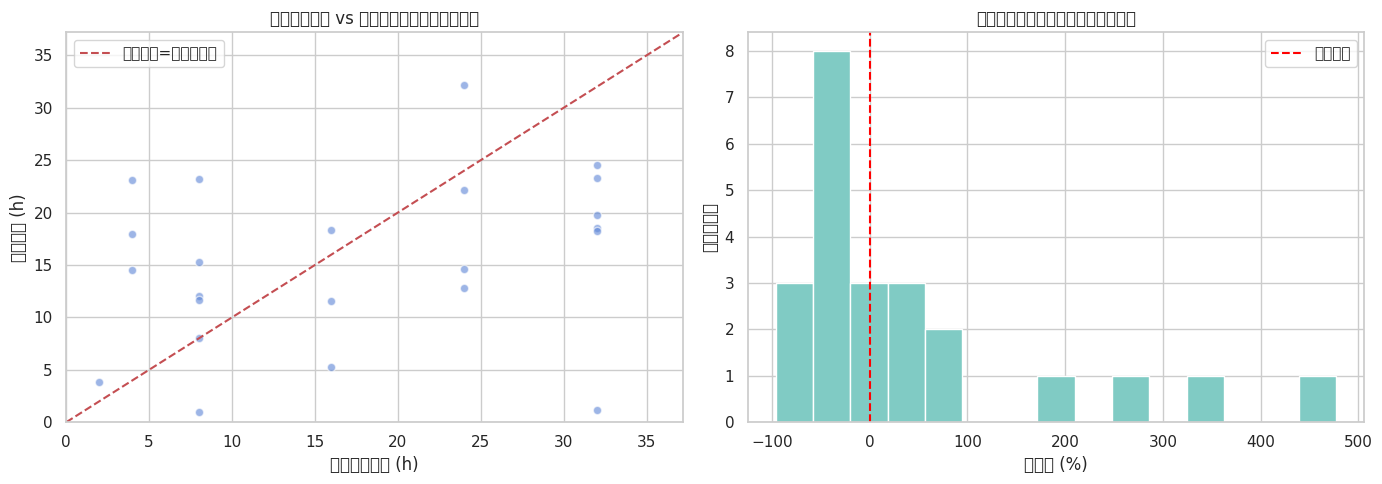

平均乖離率: 46.1%
過小見積もり（実績>見積もり）: 10 件
過大見積もり（実績<見積もり）: 12 件


In [6]:
hours_df = df[df['EstimatedHours'].notna() & (df['ActualHours'] > 0) & (df['Status'] == 'done')].copy()
hours_df['乖離率(%)'] = ((hours_df['ActualHours'] - hours_df['EstimatedHours']) / hours_df['EstimatedHours'] * 100).round(1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
max_h = max(hours_df['EstimatedHours'].max(), hours_df['ActualHours'].max()) + 5
axes[0].scatter(hours_df['EstimatedHours'], hours_df['ActualHours'], alpha=0.6, color='#5C85D6', edgecolors='white')
axes[0].plot([0, max_h], [0, max_h], 'r--', linewidth=1.5, label='見積もり=実績ライン')
axes[0].set_xlim(0, max_h)
axes[0].set_ylim(0, max_h)
axes[0].set_title('見積もり工数 vs 実績工数（完了チケット）')
axes[0].set_xlabel('見積もり工数 (h)')
axes[0].set_ylabel('実績工数 (h)')
axes[0].legend()
axes[1].hist(hours_df['乖離率(%)'], bins=15, color='#80CBC4', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='乖離なし')
axes[1].set_title('工数乖離率の分布（完了チケット）')
axes[1].set_xlabel('乖離率 (%)')
axes[1].set_ylabel('チケット数')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f'平均乖離率: {hours_df["乖離率(%)"].mean():.1f}%')
print(f'過小見積もり（実績>見積もり）: {(hours_df["乖離率(%)"] > 0).sum()} 件')
print(f'過大見積もり（実績<見積もり）: {(hours_df["乖離率(%)"] < 0).sum()} 件')

## 6. ベロシティ将来予測（線形回帰）

過去のスプリントのベロシティデータを基に、線形回帰で将来3スプリントを予測します。

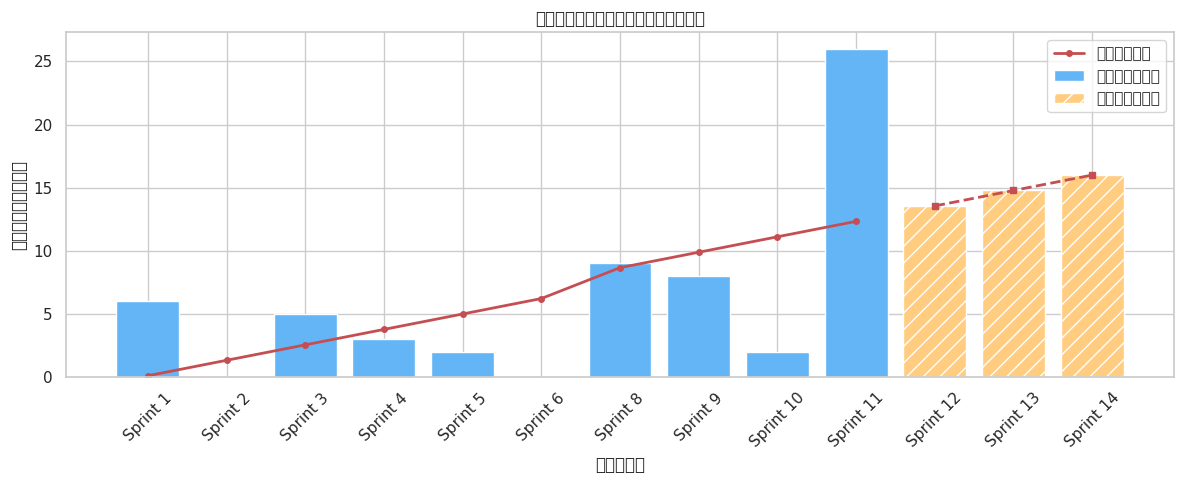

== 予測ベロシティ ==
  Sprint 12: 13.6 SP
  Sprint 13: 14.8 SP
  Sprint 14: 16.0 SP

線形回帰係数: 1.22 SP/スプリント
トレンド: 上昇傾向（1スプリントあたり 1.22 SP変化）


In [7]:
model = None
y_pred_future = np.array([])
if len(velocity) >= 3:
    X = velocity['スプリント番号'].values.reshape(-1, 1)
    y = velocity['完了ストーリーポイント'].values
    model = LinearRegression()
    model.fit(X, y)
    last_sprint = int(velocity['スプリント番号'].max())
    future_sprints = np.array([[last_sprint + 1], [last_sprint + 2], [last_sprint + 3]])
    y_pred_future = model.predict(future_sprints)
    y_pred_all = model.predict(X)
    fig, ax = plt.subplots(figsize=(12, 5))
    sprint_labels_hist = [f'Sprint {int(s)}' for s in velocity['スプリント番号']]
    future_labels = [f'Sprint {last_sprint + i}' for i in range(1, 4)]
    ax.bar(sprint_labels_hist, velocity['完了ストーリーポイント'].values, color='#64B5F6', label='実績ベロシティ', edgecolor='white')
    ax.bar(future_labels, y_pred_future.clip(0), color='#FFCC80', label='予測ベロシティ', edgecolor='white', hatch='//')
    ax.plot(sprint_labels_hist, y_pred_all, 'r-o', linewidth=2, markersize=4, label='回帰トレンド')
    ax.plot(future_labels, y_pred_future.clip(0), 'r--s', linewidth=2, markersize=5)
    ax.set_title('ベロシティ将来予測（ゲーム開発部）')
    ax.set_xlabel('スプリント')
    ax.set_ylabel('ストーリーポイント')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print('== 予測ベロシティ ==')
    for sprint, pred in zip(future_labels, y_pred_future):
        print(f'  {sprint}: {max(0, pred):.1f} SP')
    print(f'\n線形回帰係数: {model.coef_[0]:.2f} SP/スプリント')
    trend = '上昇' if model.coef_[0] > 0 else '低下'
    print(f'トレンド: {trend}傾向（1スプリントあたり {abs(model.coef_[0]):.2f} SP変化）')
else:
    print('スプリントデータが不足しているため予測をスキップします')

## 7. ブロッカー分析

`blocked` ステータスのチケットはスプリントの進行を妨げるリスク要因です。

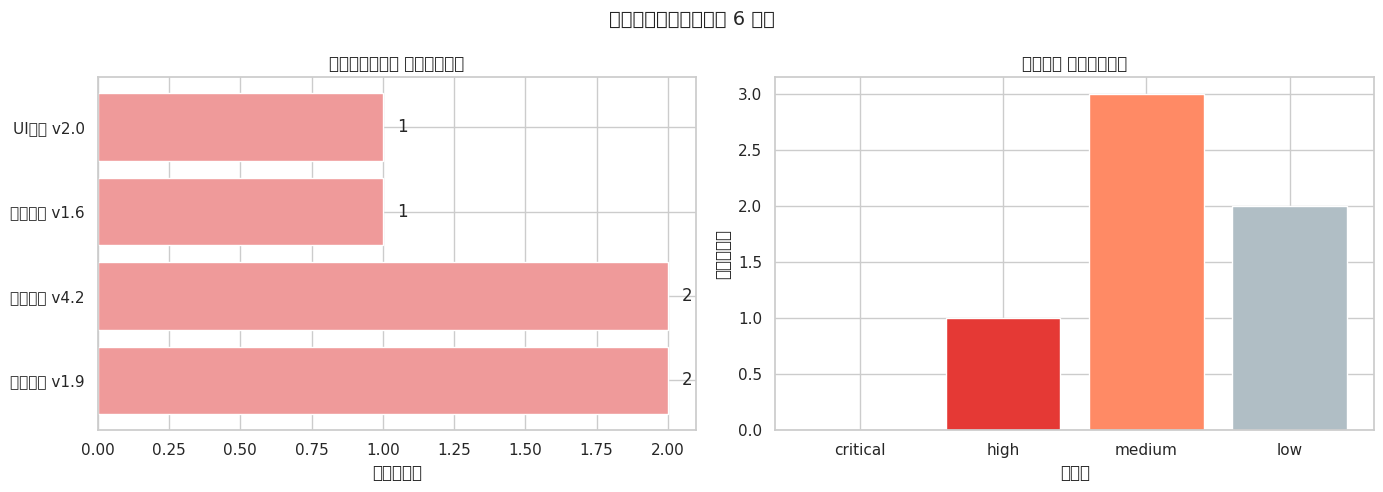

ブロッカーチケット一覧:
         ProjectName                    Title Priority SprintName AssigneeName
プロジェクト 01: 基盤刷新 v1.9               モバイル対応 #20      low   Sprint 2        山田 千夏
プロジェクト 01: 基盤刷新 v1.9          テストカバレッジの向上 #36   medium        NaN        前田 なお
プロジェクト 25: 基盤刷新 v1.6             検索機能の改善 #695   medium   Sprint 4        鈴木 健二
プロジェクト 32: 機能追加 v4.2  UIコンポーネントのリファクタリング #831      low  Sprint 11        佐藤 浩二
プロジェクト 32: 機能追加 v4.2         セキュリティパッチ適用 #848   medium   Sprint 6        鈴木 健二
プロジェクト 50: UI改善 v2.0 UIコンポーネントのリファクタリング #1306     high   Sprint 6        青木 結衣


In [8]:
blocked_df = df[df['Status'] == 'blocked'].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if len(blocked_df) > 0:
    blocked_by_proj = blocked_df['ProjectName'].value_counts()
    blocked_by_proj.index = blocked_by_proj.index.str.replace(r'プロジェクト \d+: ', '', regex=True)
    axes[0].barh(blocked_by_proj.index, blocked_by_proj.values, color='#EF9A9A', edgecolor='white')
    axes[0].set_title('プロジェクト別 ブロッカー数')
    axes[0].set_xlabel('チケット数')
    for i, v in enumerate(blocked_by_proj.values):
        axes[0].text(v + 0.05, i, str(v), va='center')
    blocked_by_priority = blocked_df['Priority'].value_counts().reindex(['critical', 'high', 'medium', 'low'], fill_value=0)
    colors_b = ['#B71C1C', '#E53935', '#FF8A65', '#B0BEC5']
    axes[1].bar(blocked_by_priority.index, blocked_by_priority.values, color=colors_b, edgecolor='white')
    axes[1].set_title('優先度別 ブロッカー数')
    axes[1].set_xlabel('優先度')
    axes[1].set_ylabel('チケット数')
else:
    for ax in axes:
        ax.text(0.5, 0.5, 'ブロッカーなし', ha='center', va='center', transform=ax.transAxes)
plt.suptitle(f'ブロッカー分析（合計 {len(blocked_df)} 件）', fontsize=14)
plt.tight_layout()
plt.show()
if len(blocked_df) > 0:
    print('ブロッカーチケット一覧:')
    print(blocked_df[['ProjectName', 'Title', 'Priority', 'SprintName', 'AssigneeName']].to_string(index=False))

## 8. 分析サマリー

In [9]:
print('=' * 60)
print('  ゲーム開発部（コンシューマーゲーム事業部）開発状況サマリー')
print('=' * 60)
total = len(df)
done_count = (df['Status'] == 'done').sum()
blocked_count = (df['Status'] == 'blocked').sum()
in_progress_count = (df['Status'] == 'in_progress').sum()
review_count = (df['Status'] == 'review').sum()
open_count = (df['Status'] == 'open').sum()
print(f'\n■ チケット概要')
print(f'  総チケット数    : {total} 件')
print(f'  完了            : {done_count} 件 ({done_count/total*100:.1f}%)')
print(f'  進行中          : {in_progress_count} 件 ({in_progress_count/total*100:.1f}%)')
print(f'  レビュー待ち    : {review_count} 件 ({review_count/total*100:.1f}%)')
print(f'  未着手          : {open_count} 件 ({open_count/total*100:.1f}%)')
print(f'  ブロッカー      : {blocked_count} 件 ({blocked_count/total*100:.1f}%)')
print(f'\n■ スクラムメトリクス')
if len(velocity) > 0:
    print(f'  スプリント数      : {len(velocity)} スプリント')
    print(f'  平均ベロシティ    : {velocity["完了ストーリーポイント"].mean():.1f} SP/スプリント')
    print(f'  最大ベロシティ    : {velocity["完了ストーリーポイント"].max():.0f} SP')
    print(f'  最小ベロシティ    : {velocity["完了ストーリーポイント"].min():.0f} SP')
if len(hours_df) > 0:
    avg_deviation = hours_df['乖離率(%)'].mean()
    direction = '超過' if avg_deviation > 0 else '余裕'
    print(f'\n■ 工数見積もり精度')
    print(f'  分析対象（完了チケット）: {len(hours_df)} 件')
    print(f'  平均工数乖離率    : {avg_deviation:+.1f}% ({direction}傾向)')
print(f'\n■ リスク')
if blocked_count > 0:
    high_priority_blocked = blocked_df[blocked_df['Priority'].isin(['high', 'critical'])]
    print(f'  ブロッカー {blocked_count} 件のうち高優先度: {len(high_priority_blocked)} 件')
    print(f'  → スプリントレビューでのブロッカー解消を優先してください')
else:
    print(f'  現在ブロッカーはありません')
if model is not None:
    trend_val = model.coef_[0]
    if trend_val > 0:
        print(f'\n■ 将来予測')
        print(f'  ベロシティは上昇傾向（+{trend_val:.2f} SP/スプリント）')
        print(f'  次スプリント予測ベロシティ: {max(0, y_pred_future[0]):.1f} SP')
    elif trend_val < 0:
        print(f'\n■ 将来予測（注意）')
        print(f'  ベロシティは低下傾向（{trend_val:.2f} SP/スプリント）')
        print(f'  チームキャパシティや技術的負債の見直しを検討してください')
    else:
        print(f'\n■ 将来予測')
        print(f'  ベロシティは安定推移')
print('\n' + '=' * 60)

  ゲーム開発部（コンシューマーゲーム事業部）開発状況サマリー

■ チケット概要
  総チケット数    : 104 件
  完了            : 23 件 (22.1%)
  進行中          : 35 件 (33.7%)
  レビュー待ち    : 16 件 (15.4%)
  未着手          : 24 件 (23.1%)
  ブロッカー      : 6 件 (5.8%)

■ スクラムメトリクス
  スプリント数      : 10 スプリント
  平均ベロシティ    : 6.1 SP/スプリント
  最大ベロシティ    : 26 SP
  最小ベロシティ    : 0 SP

■ 工数見積もり精度
  分析対象（完了チケット）: 23 件
  平均工数乖離率    : +46.1% (超過傾向)

■ リスク
  ブロッカー 6 件のうち高優先度: 1 件
  → スプリントレビューでのブロッカー解消を優先してください

■ 将来予測
  ベロシティは上昇傾向（+1.22 SP/スプリント）
  次スプリント予測ベロシティ: 13.6 SP

